# Datenbeschreibung und Explorative Datenanalyse

Im Rahmen dieser Leistungsbewertung wird ein Datensatz zur Vorhersage von Herzkrankheiten analysiert.

Der Datensatz enthält klinische und diagnostische Messwerte von Patienten wie Alter, Blutdruck, Cholesterinwerte sowie Ergebnisse aus Belastungstests und EKG-Untersuchungen.

Ziel dieses Notebooks ist es, die Struktur des Datensatzes zu untersuchen, eine geeignete Zielvariable zu definieren und erste statistische Analysen durchzuführen.

Die explorative Datenanalyse umfasst:

- Überblick über den Datensatz
- Identifikation der Zielvariable
- Unterscheidung zwischen numerischen und kategorischen Variablen
- Berechnung statistischer Kennzahlen
- Analyse von Verteilungen
- Untersuchung von Korrelationen
- Überprüfung der Datenqualität

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("test.csv", sep=";")
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


## Überblick über den Datensatz


In [7]:
df.shape

(270000, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: float64(1), 

Die Funktion `df.info()` zeigt eine Übersicht über die Struktur des Datensatzes.

Der Datensatz enthält insgesamt 270'000 Beobachtungen und 14 Variablen.

Alle Variablen sind als numerische Werte gespeichert (`int64` oder `float64`). Einige dieser Variablen stellen jedoch kategoriale Informationen dar, die lediglich numerisch codiert wurden (z.B. Geschlecht oder Brustschmerztyp).

Die Übersicht zeigt außerdem, dass keine fehlenden Werte vorhanden sind, da jede Variable die gleiche Anzahl an Einträgen aufweist.

## Einteilung der Variablen

Obwohl alle Variablen im Datensatz numerisch gespeichert sind, stellen einige davon kategoriale Informationen dar. 

Daher werden die Variablen in zwei Gruppen eingeteilt:

- numerische Variablen (kontinuierliche Messwerte)
- kategoriale Variablen (diskrete Kategorien, numerisch codiert)

In [9]:
numerical_features = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

categorical_features = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]

print("Numerische Variablen:")
print(numerical_features)

print("\nKategorische Variablen:")
print(categorical_features)

Numerische Variablen:
['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

Kategorische Variablen:
['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


Die numerischen Variablen stellen kontinuierliche medizinische Messwerte dar, wie beispielsweise Alter, Blutdruck oder Cholesterinwerte.

Die kategorialen Variablen hingegen repräsentieren diskrete Kategorien, die lediglich numerisch codiert wurden. Dazu gehören beispielsweise Geschlecht, Brustschmerztyp oder Ergebnisse diagnostischer Tests.

Diese Unterscheidung ist wichtig, da unterschiedliche Datentypen später unterschiedlich im Machine-Learning-Modell verarbeitet werden müssen.

In [10]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
mean,764999.500000,54.159870,0.716315,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,77942.430678,8.255471,0.450787,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,630000.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,697499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,764999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,832499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000
max,899999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.00000,7.000000


## Statistische Beschreibung der Variablen

Die Funktion `df.describe()` liefert grundlegende statistische Kennzahlen für alle numerischen Variablen im Datensatz.

Dazu gehören unter anderem:

- Mittelwert (`mean`)
- Standardabweichung (`std`)
- Minimum (`min`)
- Maximum (`max`)
- Quartile (25%, 50%, 75%)

Diese Kennzahlen geben einen ersten Überblick über die Verteilung der medizinischen Messwerte.

Beispielsweise liegt das durchschnittliche Alter der Patienten bei etwa 54 Jahren. Der durchschnittliche Cholesterinwert beträgt ungefähr 245, während die maximale Herzfrequenz im Durchschnitt bei etwa 152 liegt.

Solche Kennzahlen helfen dabei, typische Wertebereiche zu erkennen und mögliche Ausreißer zu identifizieren.

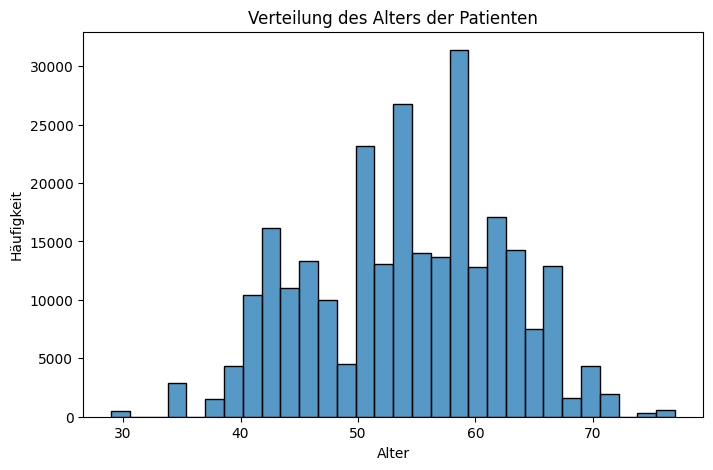

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30)

plt.title("Verteilung des Alters der Patienten")
plt.xlabel("Alter")
plt.ylabel("Häufigkeit")

plt.show()

### Verteilung des Alters der Patienten

Die Grafik zeigt die Verteilung des Alters der Patienten im Datensatz.

Die meisten Patienten befinden sich im mittleren Erwachsenenalter. Besonders häufig treten Alterswerte zwischen etwa 45 und 65 Jahren auf.

Diese Altersverteilung ist plausibel, da Herzkrankheiten häufiger bei Personen im mittleren und höheren Alter auftreten.

In [12]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

## Überprüfung auf fehlende Werte

Zur Sicherstellung der Datenqualität wurde überprüft, ob fehlende Werte im Datensatz vorhanden sind.

Die Analyse zeigt, dass keine fehlenden Werte existieren, da alle Variablen für jede Beobachtung einen Eintrag besitzen.

Dies ist vorteilhaft für das Training von Machine-Learning-Modellen, da keine zusätzlichen Schritte zur Behandlung fehlender Werte erforderlich sind.

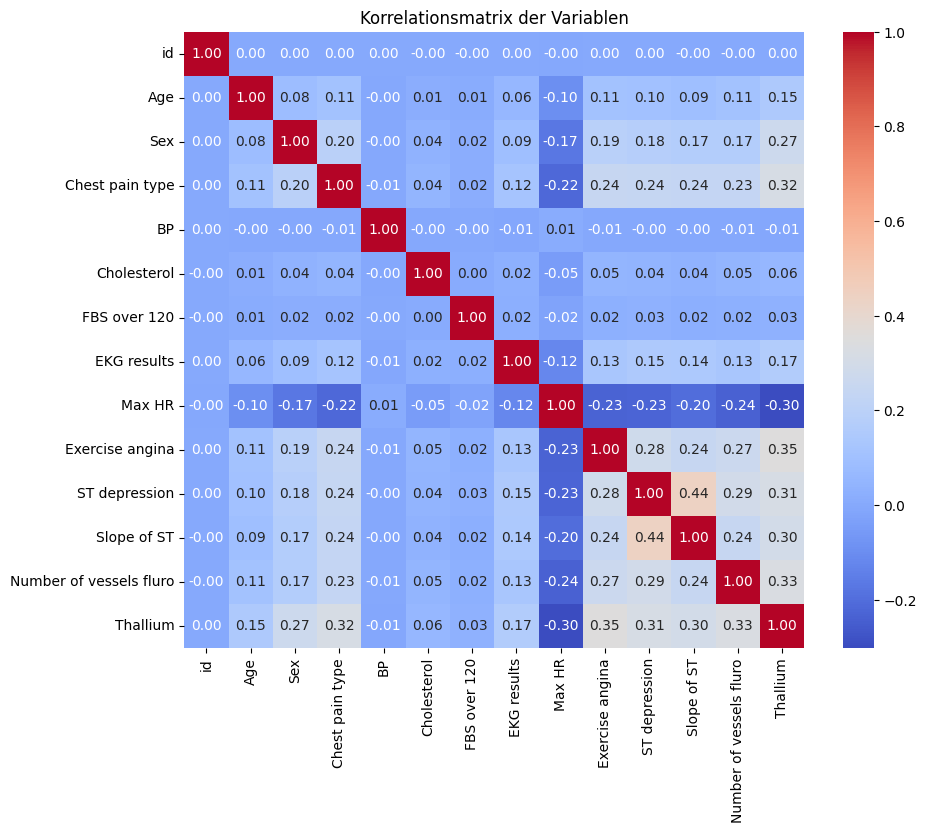

In [13]:
plt.figure(figsize=(10,8))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Korrelationsmatrix der Variablen")

plt.show()

## Korrelationsanalyse

Zur Untersuchung möglicher Zusammenhänge zwischen den Variablen wurde eine Korrelationsmatrix erstellt.

Die Matrix zeigt den linearen Zusammenhang zwischen allen numerischen Variablen im Datensatz. Werte nahe 1 oder -1 deuten auf einen starken Zusammenhang hin, während Werte nahe 0 auf einen schwachen oder keinen Zusammenhang hinweisen.

Solche Analysen sind hilfreich, um potenziell wichtige Prädiktoren für spätere Machine-Learning-Modelle zu identifizieren.

## Interpretation der Korrelationsmatrix

Die Korrelationsmatrix zeigt die linearen Zusammenhänge zwischen den verschiedenen Variablen des Datensatzes.

Die meisten Variablen weisen nur schwache Korrelationen miteinander auf, was darauf hindeutet, dass sie weitgehend unabhängige Informationen liefern.

Ein moderater Zusammenhang ist beispielsweise zwischen **ST depression** und **Slope of ST** zu erkennen. Dies ist plausibel, da beide Variablen mit Veränderungen im ST-Segment des EKGs zusammenhängen.

Auch **Thallium**, **Exercise angina** und **Number of vessels fluro** zeigen gewisse Zusammenhänge mit anderen Variablen, was darauf hindeutet, dass diese Merkmale möglicherweise wichtige Hinweise auf Herzkrankheiten liefern könnten.

Die Variable **id** zeigt erwartungsgemäß keine Korrelation mit anderen Variablen, da sie lediglich eine Identifikationsnummer darstellt.

Die Variable **id** stellt lediglich eine Identifikationsnummer dar und enthält keine medizinische Information. 

Daher wird sie in späteren Machine-Learning-Schritten nicht als Eingangsvariable verwendet.